# Khám phá và Phân tích Dữ liệu (Exploratory Data Analysis - EDA)

**Giai đoạn 1: Xử lý dữ liệu** trong dự án **Automated Essay Scoring (AES)**.
Mục tiêu chính là phân tích dữ liệu gốc từ thư mục `data/raw/` để phát hiện các đặc tính thống kê, lỗi dữ liệu, giá trị khuyết thiếu và hiện tượng rò rỉ dữ liệu (data leakage) trước khi tiến hành làm sạch.

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình hiển thị biểu đồ
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Tải các tệp dữ liệu thô

Đường dẫn tương đối được xác định từ thư mục chứa notebook (`notebooks/`) trỏ ra ngoài `data/raw/`.

In [2]:
DATA_RAW_DIR = "../data/raw"

train_path = os.path.join(DATA_RAW_DIR, "dataset", "train_final.csv")
test_path = os.path.join(DATA_RAW_DIR, "dataset", "test_final.csv")
collected_path = os.path.join(DATA_RAW_DIR, "Raw IELTS essays", "collected_ielts_data.csv")

print("Đang đọc dữ liệu từ data/raw...")
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)
df_collected = pd.read_csv(collected_path)

print(f"Tập Train (train_final.csv): {df_train.shape[0]} dòng, {df_train.shape[1]} cột")
print(f"Tập Test (test_final.csv): {df_test.shape[0]} dòng, {df_test.shape[1]} cột")
print(f"Tập Collected (collected_ielts_data.csv): {df_collected.shape[0]} dòng, {df_collected.shape[1]} cột")

Đang đọc dữ liệu từ data/raw...
Tập Train (train_final.csv): 9833 dòng, 18 cột
Tập Test (test_final.csv): 495 dòng, 17 cột
Tập Collected (collected_ielts_data.csv): 6943 dòng, 14 cột


### Kiểm tra các cột trong mỗi DataFrame

In [3]:
print("Cột trong df_train:", df_train.columns.tolist())
print("\nCột trong df_test:", df_test.columns.tolist())
print("\nCột trong df_collected:", df_collected.columns.tolist())

Cột trong df_train: ['band', 'prompt', 'essay', 'TR_Band', 'TR_Comment', 'CC_Band', 'CC_Comment', 'LR_Band', 'LR_Mistakes', 'LR_Corrections', 'LR_Comment', 'GRA_Band', 'GRA_Mistakes', 'GRA_Corrections', 'GRA_Comment', 'Overall_Band', 'General_Feedback', 'error']

Cột trong df_test: ['band', 'prompt', 'essay', 'TR_Band', 'TR_Comment', 'CC_Band', 'CC_Comment', 'LR_Band', 'LR_Mistakes', 'LR_Corrections', 'LR_Comment', 'GRA_Band', 'GRA_Mistakes', 'GRA_Corrections', 'GRA_Comment', 'Overall_Band', 'General_Feedback']

Cột trong df_collected: ['Unnamed: 0', 'title', 'text', 'overall_score', 'vocabulary_level', 'grammar_mistakes', 'task_response', 'task_response_description', 'coherence_and_cohesion', 'coherence_and_cohesion_description', 'lexical_resource', 'lexical_resource_description', 'grammatical_range_and_accuracy', 'grammatical_range_and_accuracy_text']


## 2. Phân tích phân phối của cột Overall_Band

Chúng ta xem xét dải điểm `Overall_Band` trong tập Train và tập Test.

Tập Train - Thống kê cột Overall_Band:
Overall_Band
2.0       9
2.5      18
3.0     236
3.5     307
4.0     601
4.5     647
5.0    1051
5.5     956
6.0    1144
6.5    1169
7.0    1359
7.5    1104
8.0     697
8.5     431
9.0     104
Name: count, dtype: int64

Tập Test - Thống kê cột Overall_Band:
Overall_Band
2.0     1
2.5     4
3.0    10
3.5    12
4.0    29
4.5    26
5.0    48
5.5    53
6.0    64
6.5    55
7.0    74
7.5    63
8.0    35
8.5    17
9.0     4
Name: count, dtype: int64


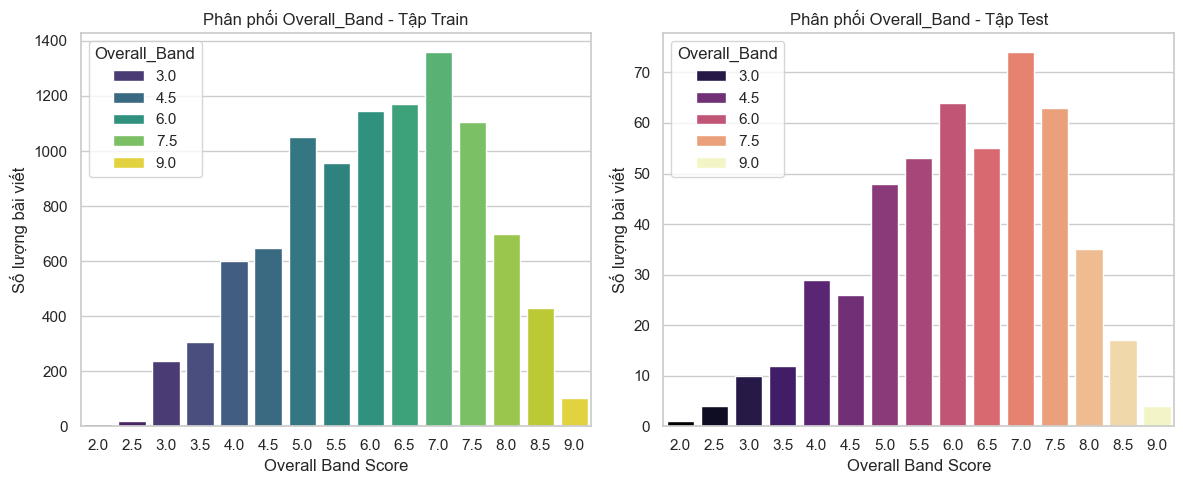

In [5]:
print("Tập Train - Thống kê cột Overall_Band:")
print(df_train['Overall_Band'].value_counts().sort_index())
print("\nTập Test - Thống kê cột Overall_Band:")
print(df_test['Overall_Band'].value_counts().sort_index())

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df_train, x='Overall_Band', hue='Overall_Band', ax=axes[0], palette="viridis")
axes[0].set_title("Phân phối Overall_Band - Tập Train")
axes[0].set_xlabel("Overall Band Score")
axes[0].set_ylabel("Số lượng bài viết")

sns.countplot(data=df_test, x='Overall_Band', hue='Overall_Band', ax=axes[1], palette="magma")
axes[1].set_title("Phân phối Overall_Band - Tập Test")
axes[1].set_xlabel("Overall Band Score")
axes[1].set_ylabel("Số lượng bài viết")

plt.tight_layout()
plt.show()

## 3. Thống kê độ dài văn bản (Word Count)

Độ dài bài thi IELTS Writing Task 2 tiêu chuẩn cần đạt tối thiểu 250 từ.

Tập Train - Độ dài bài viết (từ):
count    9833.000000
mean      292.681989
std        57.997544
min         1.000000
25%       263.000000
50%       289.000000
75%       322.000000
max      1557.000000
Name: word_count, dtype: float64

Tập Test - Độ dài bài viết (từ):
count    495.000000
mean     293.884848
std       56.251791
min       52.000000
25%      264.000000
50%      290.000000
75%      322.500000
max      574.000000
Name: word_count, dtype: float64

Tập Collected - Độ dài bài viết (từ):
count    6943.000000
mean      298.937923
std        57.772662
min        88.000000
25%       263.000000
50%       289.000000
75%       326.000000
max       858.000000
Name: word_count, dtype: float64


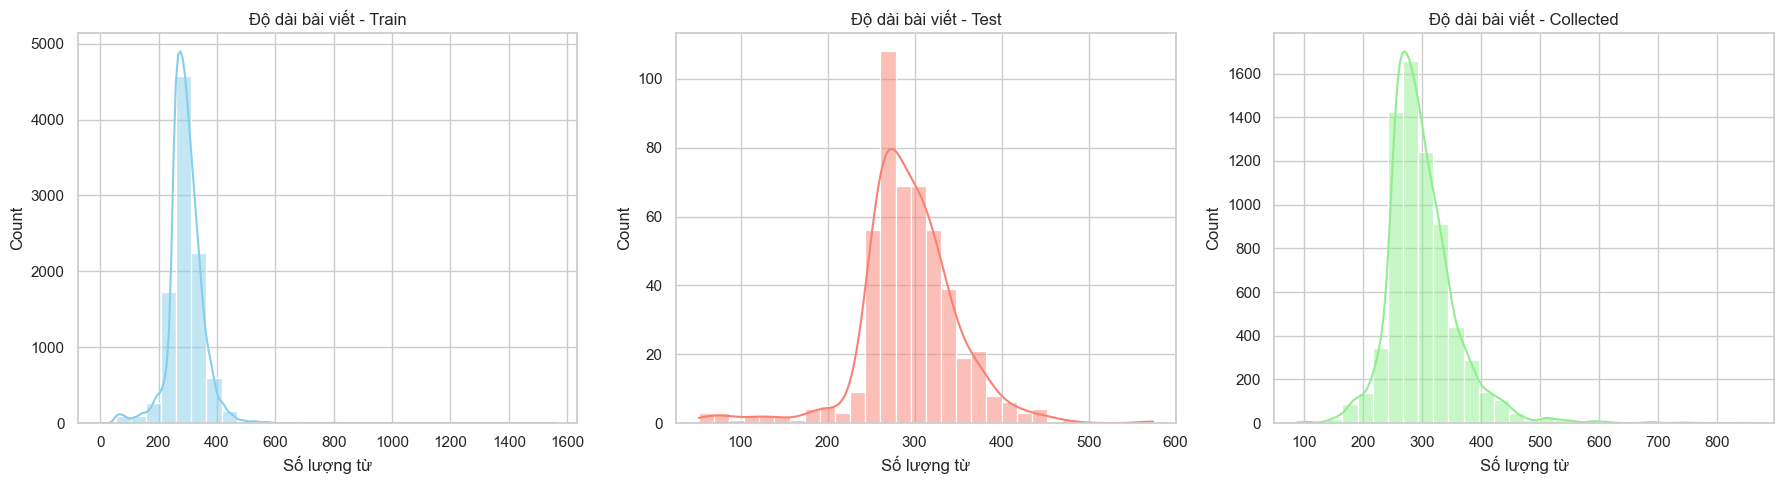

In [6]:
df_train['word_count'] = df_train['essay'].apply(lambda x: len(str(x).split()))
df_test['word_count'] = df_test['essay'].apply(lambda x: len(str(x).split()))
df_collected['word_count'] = df_collected['text'].apply(lambda x: len(str(x).split()))

print("Tập Train - Độ dài bài viết (từ):")
print(df_train['word_count'].describe())

print("\nTập Test - Độ dài bài viết (từ):")
print(df_test['word_count'].describe())

print("\nTập Collected - Độ dài bài viết (từ):")
print(df_collected['word_count'].describe())

# Vẽ Histogram
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_train['word_count'], bins=30, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Độ dài bài viết - Train")
axes[0].set_xlabel("Số lượng từ")

sns.histplot(df_test['word_count'], bins=30, kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Độ dài bài viết - Test")
axes[1].set_xlabel("Số lượng từ")

sns.histplot(df_collected['word_count'], bins=30, kde=True, ax=axes[2], color="lightgreen")
axes[2].set_title("Độ dài bài viết - Collected")
axes[2].set_xlabel("Số lượng từ")

plt.tight_layout()
plt.show()

## 4. Kiểm tra các giá trị khuyết thiếu (NaN) và các ký tự thừa (\n, \r)

In [7]:
print("=== Giá trị khuyết thiếu trong tập Train ===")
print(df_train.isnull().sum()[df_train.isnull().sum() > 0])

print("\n=== Giá trị khuyết thiếu trong tập Test ===")
print(df_test.isnull().sum()[df_test.isnull().sum() > 0])

print("\n=== Giá trị khuyết thiếu trong tập Collected ===")
print(df_collected.isnull().sum()[df_collected.isnull().sum() > 0])

=== Giá trị khuyết thiếu trong tập Train ===
LR_Mistakes          33
LR_Corrections       35
GRA_Mistakes         76
GRA_Corrections      79
error              9833
dtype: int64

=== Giá trị khuyết thiếu trong tập Test ===
LR_Mistakes        4
LR_Corrections     4
GRA_Mistakes       5
GRA_Corrections    5
dtype: int64

=== Giá trị khuyết thiếu trong tập Collected ===
Series([], dtype: int64)


### Kiểm tra các ký tự xuống dòng thừa trong cột điểm và bài viết

In [8]:
def count_whitespace_chars(series):
    has_nl = series.astype(str).str.contains('\n').sum()
    has_cr = series.astype(str).str.contains('\r').sum()
    return has_nl, has_cr

print("Kiểm tra ký tự xuống dòng thừa trong các cột văn bản/cột điểm:")
for name, df, col in [("Train (essay)", df_train, "essay"), 
                      ("Train (band)", df_train, "band"),
                      ("Test (essay)", df_test, "essay"),
                      ("Test (band)", df_test, "band"),
                      ("Collected (text)", df_collected, "text")]:
    nl, cr = count_whitespace_chars(df[col])
    print(f"{name}: Chứa '\\n' = {nl} dòng | Chứa '\\r' = {cr} dòng")

Kiểm tra ký tự xuống dòng thừa trong các cột văn bản/cột điểm:
Train (essay): Chứa '\n' = 9592 dòng | Chứa '\r' = 6828 dòng
Train (band): Chứa '\n' = 545 dòng | Chứa '\r' = 4125 dòng
Test (essay): Chứa '\n' = 487 dòng | Chứa '\r' = 351 dòng
Test (band): Chứa '\n' = 37 dòng | Chứa '\r' = 190 dòng
Collected (text): Chứa '\n' = 6781 dòng | Chứa '\r' = 0 dòng


## 5. Kiểm tra sơ bộ các cột điểm thành phần (TR, CC, LR, GRA)

Phân tích mức độ tương quan chéo giữa các tiêu chí chấm điểm.

Thống kê mô tả điểm các tiêu chí thành phần (Train):
           TR_Band      CC_Band      LR_Band     GRA_Band  Overall_Band
count  9833.000000  9833.000000  9833.000000  9833.000000   9833.000000
mean      6.088071     6.258263     5.962067     5.894030      6.112580
std       1.469663     1.514169     1.407305     1.407006      1.425723
min       1.000000     2.000000     2.000000     2.000000      2.000000
25%       5.000000     5.000000     5.000000     5.000000      5.000000
50%       6.000000     6.000000     6.000000     6.000000      6.000000
75%       7.000000     7.000000     7.000000     7.000000      7.000000
max       9.000000     9.000000     9.000000     9.000000      9.000000

Ma trận tương quan giữa các tiêu chí chấm điểm:
               TR_Band   CC_Band   LR_Band  GRA_Band  Overall_Band
TR_Band       1.000000  0.946229  0.912992  0.906935      0.962257
CC_Band       0.946229  1.000000  0.939113  0.939445      0.979243
LR_Band       0.912992  0.939113  1.000000  0.967

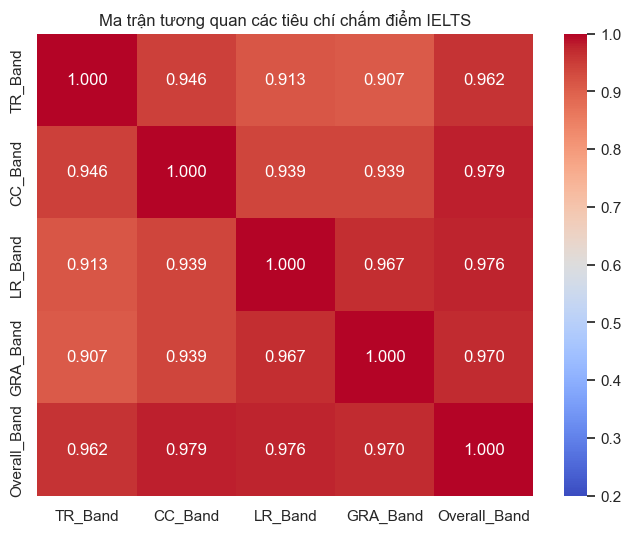

In [9]:
criteria_cols = ['TR_Band', 'CC_Band', 'LR_Band', 'GRA_Band', 'Overall_Band']

print("Thống kê mô tả điểm các tiêu chí thành phần (Train):")
print(df_train[criteria_cols].describe())

# Tính ma trận tương quan
corr_matrix = df_train[criteria_cols].corr()
print("\nMa trận tương quan giữa các tiêu chí chấm điểm:")
print(corr_matrix)

# Vẽ Heatmap tương quan
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".3f", vmin=0.2, vmax=1.0)
plt.title("Ma trận tương quan các tiêu chí chấm điểm IELTS")
plt.show()

## 6. Phát hiện rò rỉ dữ liệu (Data Leakage) và Trùng lặp

In [10]:
# 1. Trùng lặp nội bộ trong Train
train_dups = df_train.duplicated(subset=['essay']).sum()
print(f"Số lượng bài viết bị trùng lặp nội bộ trong tập Train: {train_dups} dòng")

# 2. Rò rỉ dữ liệu giữa Train và Test
leakage_count = df_train['essay'].isin(df_test['essay']).sum()
unique_test_in_train = len(set(df_test['essay'].unique()).intersection(set(df_train['essay'].unique())))
print(f"Số dòng trong Train có nội dung trùng với tập Test: {leakage_count} dòng")
print(f"Số bài viết độc bản trong Test đã xuất hiện ở Train: {unique_test_in_train} / {df_test['essay'].nunique()} bài")

# 3. Kiểm tra giao thoa giữa dữ liệu thu thập (Collected) và tập Train/Test
overlap_train_coll = len(set(df_train['essay'].unique()).intersection(set(df_collected['text'].unique())))
overlap_test_coll = len(set(df_test['essay'].unique()).intersection(set(df_collected['text'].unique())))
print(f"Mức độ giao thoa giữa Collected và Train: {overlap_train_coll} bài")
print(f"Mức độ giao thoa giữa Collected và Test: {overlap_test_coll} bài")

Số lượng bài viết bị trùng lặp nội bộ trong tập Train: 848 dòng
Số dòng trong Train có nội dung trùng với tập Test: 569 dòng
Số bài viết độc bản trong Test đã xuất hiện ở Train: 491 / 493 bài
Mức độ giao thoa giữa Collected và Train: 0 bài
Mức độ giao thoa giữa Collected và Test: 0 bài


## 7. Tổng kết Phát hiện chính từ EDA

1. **Rò rỉ dữ liệu cực kỳ nghiêm trọng:** Gần như toàn bộ bài viết trong tập Test (`test_final.csv`) đều đã có mặt trong tập Train.
2. **Trùng lặp nội bộ:** Tập Train có 848 dòng bị lặp lại nội dung bài viết. Cần thực hiện `drop_duplicates`.
3. **Ký tự xuống dòng thừa:** Cột `band` trong cả tập Train và Test chứa ký tự xuống dòng thừa `\n` và `\r`.
4. **Giá trị khuyết:** Cột `error` hoàn toàn rỗng, cần xóa bỏ. Các cột `Mistakes` và `Corrections` chứa giá trị khuyết thiếu cần được điền bằng chuỗi trống.